# Objectif 

Date : 09/10/2025

L'objectif du notebook est de localiser la source en mouvement par une méthode TOA. 

Les positions des hydrophones dans le bassin sont supposées connues et ont été préalablement estimée par TOA à l'aide des enregistrements en statique aux positions P1 à P6. 

In [1]:
import os
import sys
import scipy 
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append(r"C:\Users\baptiste.menetrier\Desktop\devPy\phd")


from misc import calc_wls, draw_ellipse
from real_data_analysis.fiberscope_20.src import params
from real_data_analysis.fiberscope_20.src.utils import load_fiberscope_data, all_arrivals_dynamic
from real_data_analysis.fiberscope_20.src.fiberscope_recording import (
    FiberscopeDynamicRecording,
)
from publication.publication_figure import PubFigure, color
PubFigure()

In [2]:
# Define usefull paths

# Raw data 
tdms_data_root = (
    r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\data\Fiberscope_campagne_oct_2024"
)

# Folder to save results
img_root = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\img\dynamic_src_localization_toa"
root_data_dyn = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\data\dynamic"

if not os.path.exists(img_root):
    os.makedirs(img_root)
if not os.path.exists(root_data_dyn):
    os.makedirs(root_data_dyn)

In [3]:
fs_dynamic = FiberscopeDynamicRecording()

# Analyse des signaux reçus 

## Chargement des signaux 

In [4]:
load_tdms_data = False

if load_tdms_data:

    date = fs_dynamic.recording_name.split("T")[0]
    data_path = os.path.join(tdms_data_root, f"Campagne_{date}")
    file_name = f"{fs_dynamic.recording_name}.tdms"
    file_path = os.path.join(data_path, file_name)

    data = load_fiberscope_data(file_path, subsampling_factor=5)

    # Save data as netcdf
    data.to_netcdf(os.path.join(root_data_dyn, f"{fs_dynamic.recording_name}.nc"))

else: 
    # Load pre-saved data
    data = xr.load_dataset(
        os.path.join(root_data_dyn, f"{fs_dynamic.recording_name}.nc")
    )

## Visualisation de quelques signaux 

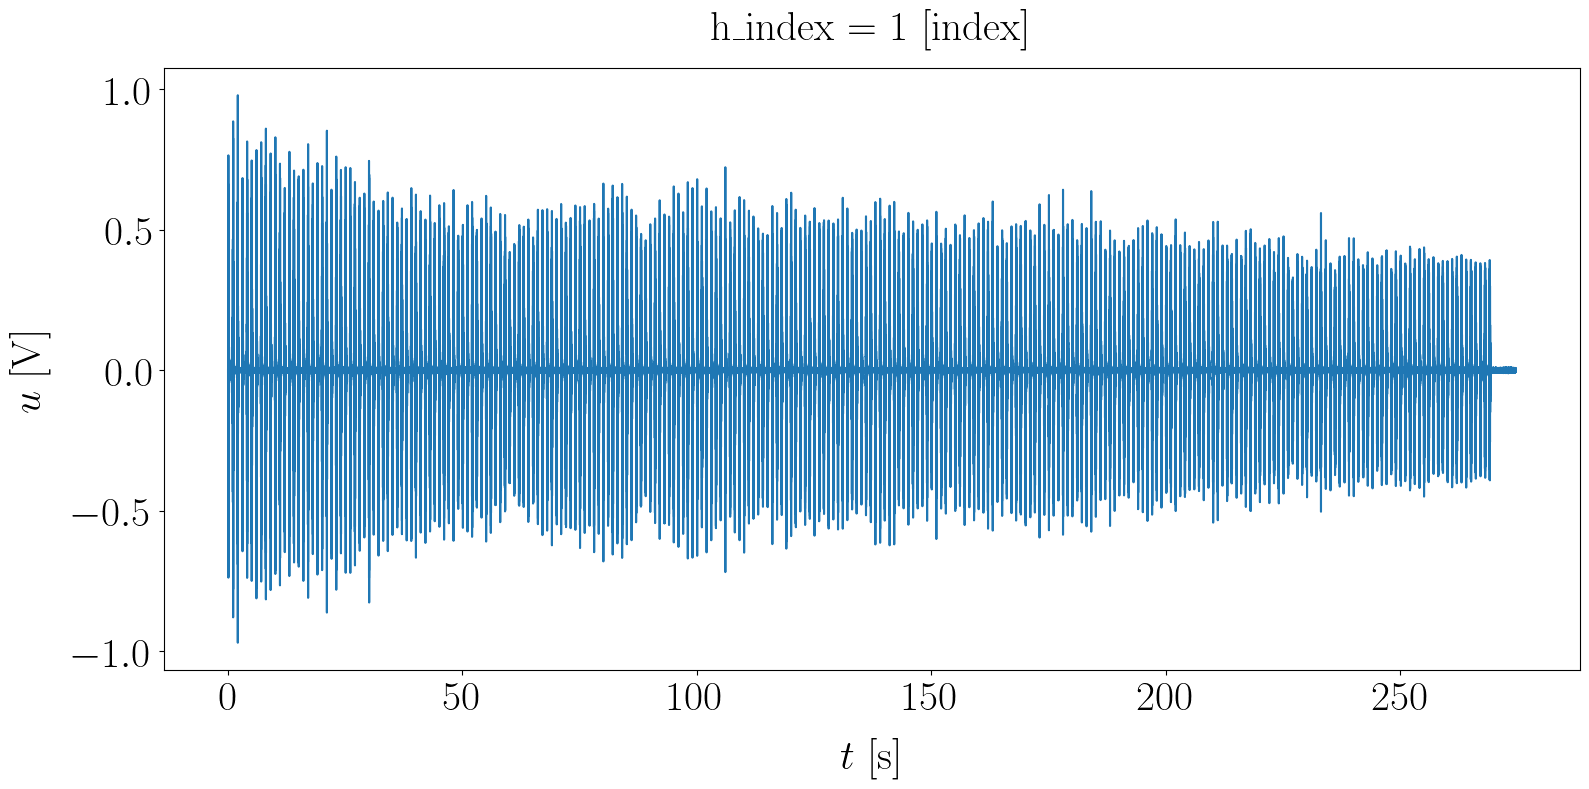

In [5]:
# Visualize single channel data
sig = data.signal.sel(h_index=1).plot()

Text(0.5, 0, 'Time [s]')

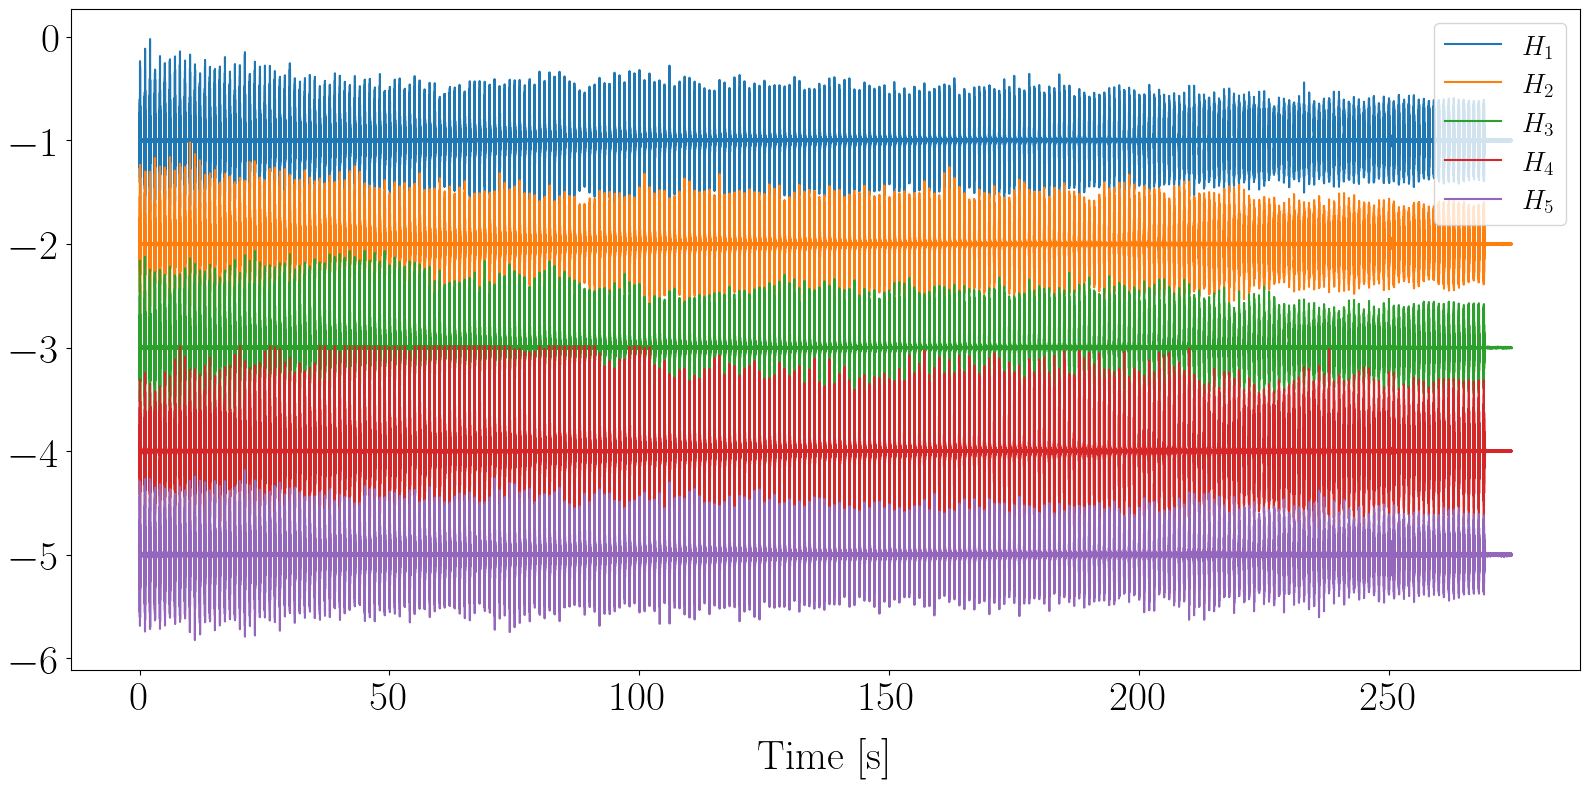

In [6]:
# Plot raw data stack plot 
delta_y = 1
plt.figure()
for i_h in data.h_index.values:
    sig = data.signal.sel(h_index=i_h).values
    plt.plot(data.time, sig - i_h * delta_y, label=rf"$H_{i_h}$")
plt.legend(loc="upper right")
plt.xlabel("Time [s]")

Text(0.5, 0, 'Time [s]')

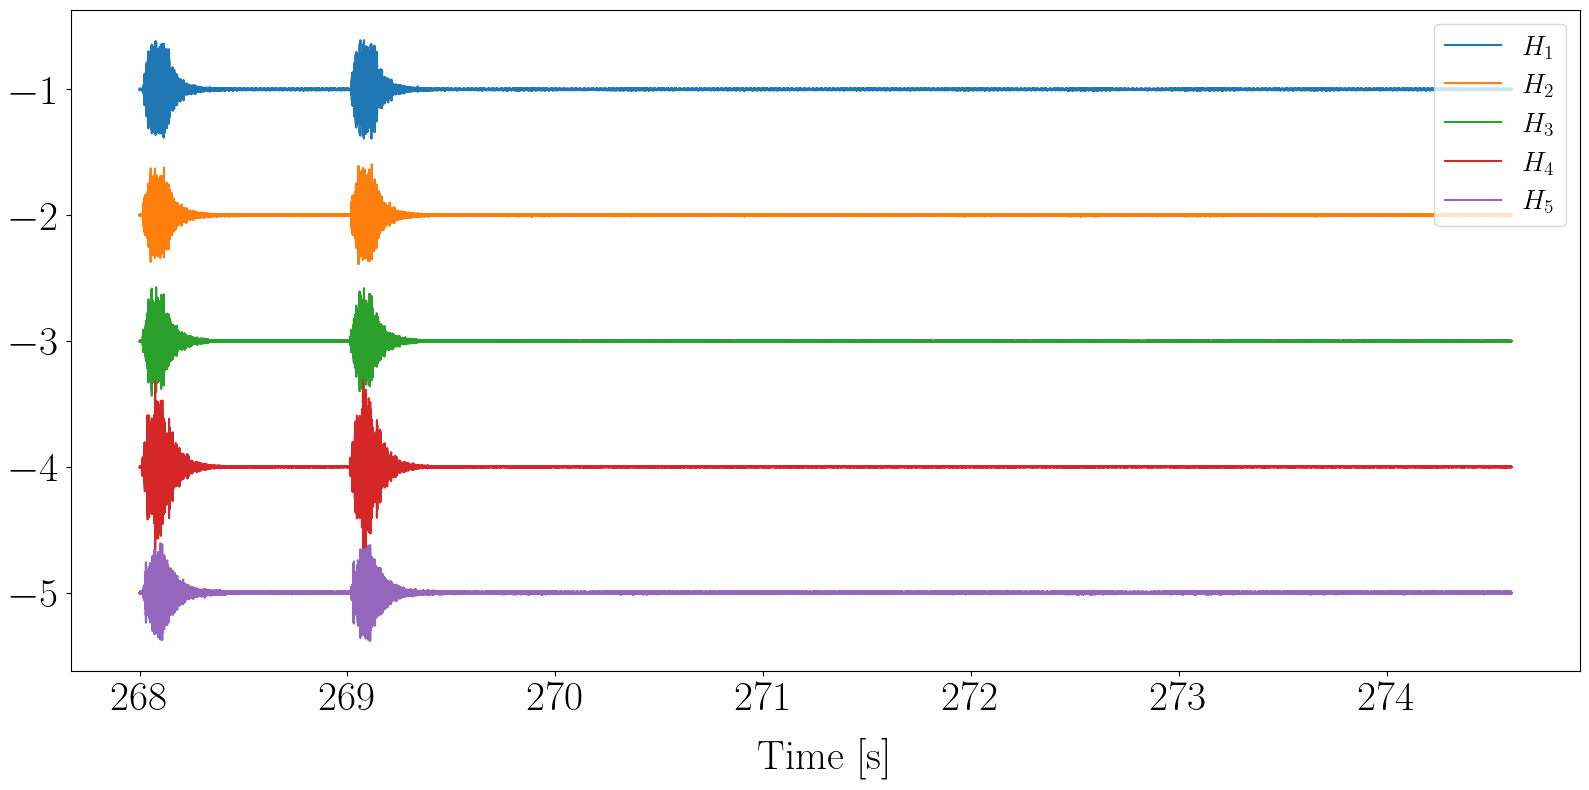

In [7]:
# ZOOM on raw data stack plot
delta_y = 1
t_min = 268
t_max = 278
plt.figure()
for i_h in data.h_index.values:
    sig = data.signal.sel(h_index=i_h).sel(time=slice(t_min, t_max))
    plt.plot(sig.time, sig - i_h * delta_y, label=rf"$H_{i_h}$")
plt.legend(loc="upper right")
plt.xlabel("Time [s]")

## Séparation signal / bruit 

In [8]:
# Show segmentation results
from real_data_analysis.fiberscope_20.src.fiberscope_manager import FiberscopeManager

root_processed_data=os.path.join(params.root_data, "localisation", "rtf_mfp")

fsm = FiberscopeManager(root_processed_data=root_processed_data)

# Set stft params
fsm.nperseg = 2**14
fsm.noverlap = int(fsm.nperseg * 0.75)

data_ = data.sel(time=slice(0, 200))
x = data_.signal.T
fs = data_.fs

ff, tt, stft_x = fsm.cm.get_stft_array(
    x, fs=fs, nperseg=fsm.nperseg, noverlap=fsm.noverlap
)

# Get mask defining signal+noise period
tt, mask_tt_x = fsm.get_signal_presence_mask(
    x, fs=fs, nperseg=fsm.nperseg, noverlap=fsm.noverlap
)
mask_tt_v = ~mask_tt_x

(0.0, 20.0)

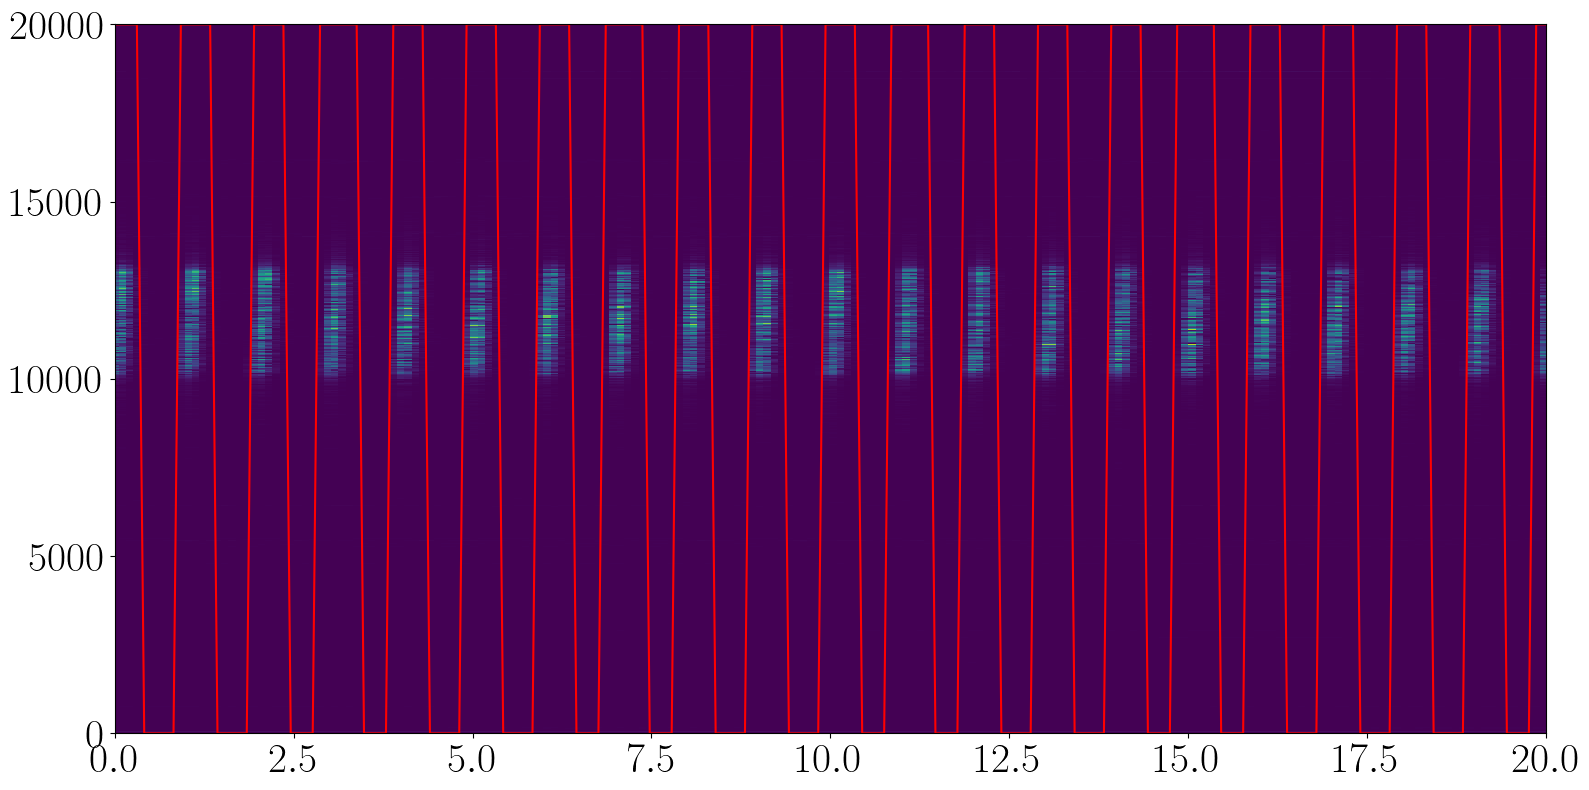

In [9]:
# Plot stft
idx_rcv = 0
plt.figure()
plt.pcolormesh(tt, ff, np.abs(stft_x[idx_rcv, ...]))

# Normalize mask
mask_tt_x_norm = mask_tt_x.astype(int) * np.max(ff)
plt.plot(tt, mask_tt_x_norm, color="r")

plt.xlim([0, 20])

## Définition de la stratégie de localisation 

La localisation est effectuée pour chacune des émissions. La trajectoire de la source est obtenue en itérant les étapes suivantes :

* 1) Détection des temps d'arrivées sur les 5 hydrophones
* 2) Calcul de la position estimée de la source par LMS 


In [10]:
# Apply to our problem
def f_d2(X, Xh):
    """
    Parameters
    ----------
    X : array
        [r, z] position of the source to estimate
    Xh : ndarray
        [[ri, zi]] positions of the hydrophones
    """
    r, z = X
    ri = Xh[0, :]
    zi = Xh[1, :]
    y = (r - ri) ** 2 + (z - zi) ** 2
    return y


def jac_d2(X, Xh):
    """
    Parameters
    ----------
    X : array
        [r, z] position of the source to estimate
    Xh : ndarray
        [[ri, zi]] positions of the hydrophones
    """

    r, z = X
    ri = Xh[0, :]
    zi = Xh[1, :]
    df_dr = 2 * (r - ri)
    df_dz = 2 * (z - zi)
    J = np.array([df_dr, df_dz]).T
    return J

In [11]:
def dynamic_localization_toa(xr_data, fs_dyn, df_hydro_pos, verbose=False):
    print("Dynamic source localization using TOA")
    print(f"Source is mooving from {fs_dyn.src_start_pos} to {fs_dyn.src_end_pos} at a speed of {fs_dyn.src_speed} m/s")
    print(f"Assumed hydrophone positions: {df_hydro_pos}")

    # Add fs info to fs_dyn
    fs_sweep_info = fs_dyn.signal
    fs_sweep_info.fs = xr_data.fs
    t_obs, d2_obs = all_arrivals_dynamic(
        xr_data=xr_data,
        fs_sweep_info=fs_sweep_info,
        c=1500,
    )

    # print(t_obs, d2_obs)

    # Inital position
    x_0 = [0, -0.001]        # Source starts at P1 which is the origin of the coordinate system
    v = fs_dyn.src_speed # m/s

    # Paramètres de la source
    tr = fs_sweep_info.interp_pulse_period
    n_sweep = fs_sweep_info.n_sweep

    hydro_pos_labels = t_obs.keys()
    Xh = np.array(
        [
            [df_hydro_pos.loc[hl].r for hl in hydro_pos_labels],
            [df_hydro_pos.loc[hl].z for hl in hydro_pos_labels],
        ]
    )

    Xs_hat = []
    Xs_res = []
    Xs_cost = []
    sigmaXs_hat = []
    # Iterate over pulses
    for i_pos in range(n_sweep):
        # Update a priori source position
        dt = i_pos * tr
        X_0 = [x_0[0] + v * dt, x_0[1]]

        y = [d2_obs[hl].flatten()[i_pos] for hl in hydro_pos_labels]
        # Weighting matrix
        W = np.eye(len(y))

        X_hat, dY_hat, cost_hat, sigmaXhat, sigma02hat = calc_wls(
            Y=y, t=Xh, X_0=X_0, W=W, fct=f_d2, jac=jac_d2, tol=1e-6, verbose=False
        )

        Xs_hat.append(X_hat)
        Xs_res.append(dY_hat)
        Xs_cost.append(cost_hat)
        sigmaXs_hat.append(sigmaXhat)

        if verbose:
            print(f"Position estimate at pulse {i_pos}: {X_hat} m")

    Xs_hat = np.array(Xs_hat)
    Xs_res = np.array(Xs_res)
    Xs_cost = np.array(Xs_cost)
    sigmaXs_hat = np.array(sigmaXs_hat)

    return t_obs, d2_obs, Xs_hat, Xs_res, Xs_cost, sigmaXs_hat

In [12]:
# Load hydrophone positions
fpath = os.path.join(
        params.root_data, "hydro_positions", "hydrophones_estimated_positions.csv"
    )

df_hydro_pos = pd.read_csv(fpath, index_col=0)

# Force H5 at the same depth as the sources 
# df_hydro_pos.loc["H5"].z = 0

In [13]:
t_obs, d2_obs, Xs_hat, Xs_res, Xs_cost, sigmaXs_hat = dynamic_localization_toa(
    xr_data=data, fs_dyn=fs_dynamic, df_hydro_pos=df_hydro_pos
)

Dynamic source localization using TOA
Source is mooving from P1 to P4 at a speed of 0.1 m/s
Assumed hydrophone positions:                 r         z
h_index                    
H1      -3.509175  4.104796
H2      -0.559483  3.969895
H3       2.396272  3.966405
H4       5.401467  3.917832
H5      -3.618455  1.418993


In [14]:
# print(f"Residuals : {Xs_res}")
print(f"Mean residual {np.mean(Xs_res)}")
print(f"Mean cost {np.mean(Xs_cost)}")

Mean residual -0.05183918624361751
Mean cost 184.60594415461713


FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\baptiste.menetrier\\Desktop\\devPy\\phd\\real_data_analysis\\fiberscope_20\\img\\localization\\toa\\dyn_pos_hat_toa_plus_ellipse.png'

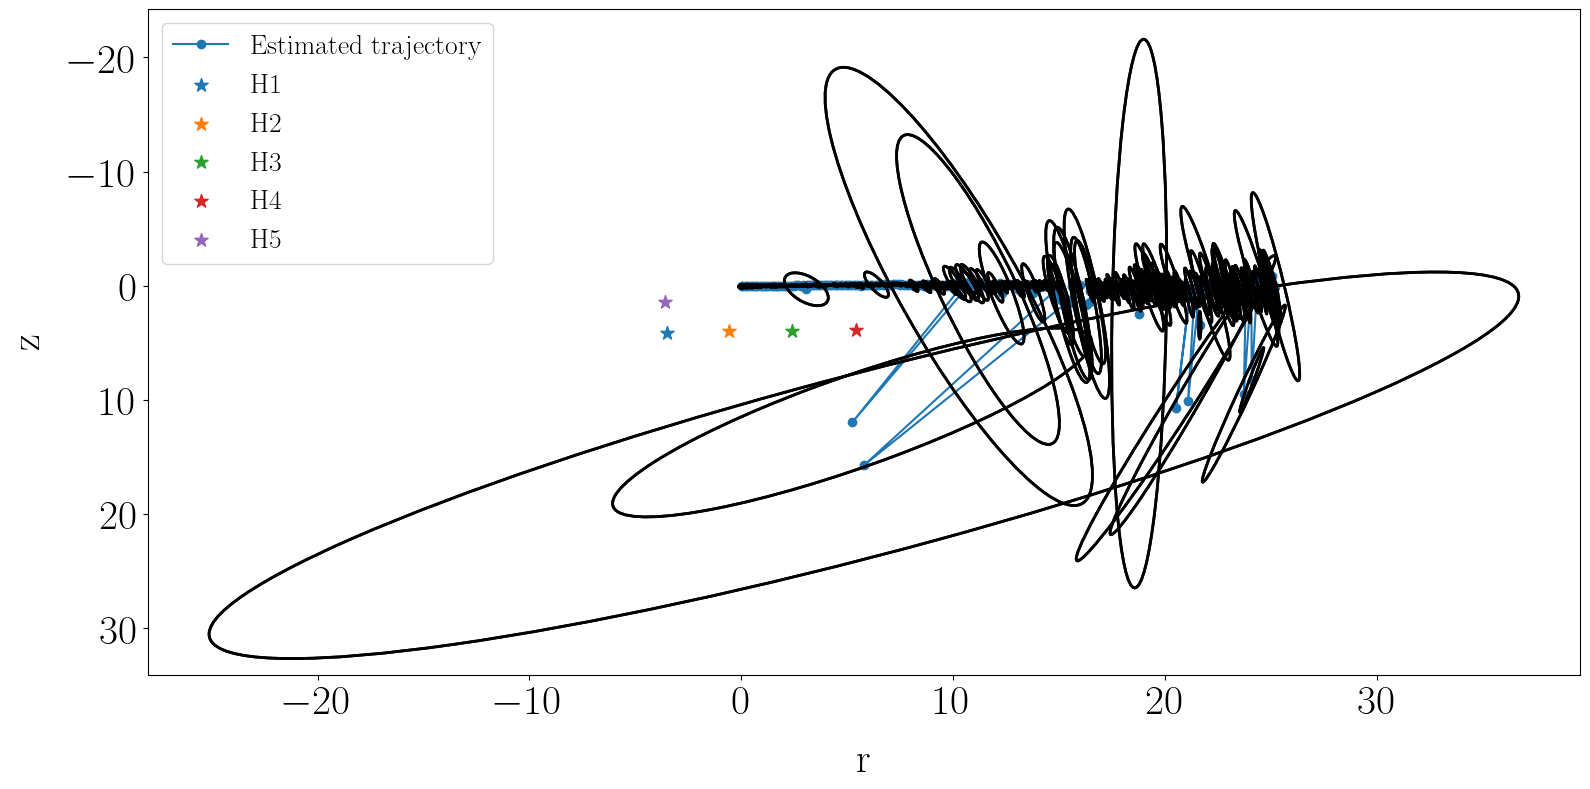

In [15]:
# Plot trajectory
# Xs_hat = Xs_hat[240:270, :]
plt.figure()
plt.plot(Xs_hat[:, 0], Xs_hat[:, 1], "-o", label="Estimated trajectory")

# Add hydrophones
for ih in df_hydro_pos.index:
    plt.scatter(
        df_hydro_pos.loc[ih].r,
        df_hydro_pos.loc[ih].z,
        marker="*",
        label=ih,
        s=100,
        # color=color(ih),
        zorder=10,
    )


alpha=0.95
nparams = Xs_hat.shape[1]
nobs = len(t_obs.keys())
ddl = nobs - nparams 
for ipos in range(Xs_hat.shape[0]):
    draw_ellipse(X=Xs_hat[ipos], SigmaX=sigmaXs_hat[ipos], ddl=ddl, alpha=alpha, title="", color="k", fac=1)

ax = plt.gca()
# ax.axis("equal")
plt.xlabel("r")
plt.ylabel("z")
# plt.xlim([15,25])
# plt.ylim([-5, 5])
ax.invert_yaxis()

# Save
img_dir = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\img\localization\toa"
fpath = os.path.join(img_dir, "dyn_pos_hat_toa_plus_ellipse.png")
plt.savefig(fpath)

In [ ]:
time_vec = np.arange(Xs_hat.shape[0]) * fs_dynamic.signal.interp_pulse_period

In [ ]:
# Linear regression to estimate the velocity of the source
tmax = 240
t_reg = time_vec[time_vec<=tmax]
r_reg = Xs_hat[:, 0][time_vec<=tmax]
result = scipy.stats.linregress(t_reg, r_reg)


print(f"Estimated velocity : {np.round(result.slope, 4)} m/s")

In [ ]:
img_dir = r"C:\Users\baptiste.menetrier\Desktop\devPy\phd\real_data_analysis\fiberscope_20\img\localisation\toa"

# Plot range vs time
plt.figure()
plt.plot(time_vec, Xs_hat[:, 0], "-o", label="Estimated range")


plt.plot(
    time_vec,
    result.slope * time_vec + result.intercept,
    color="r",
    label=f"{np.round(result.slope, 4)} t + {np.round(result.intercept, 4)}  "
    + rf"($r^2$ = {np.round(result.rvalue**2, 4)})",
)
plt.legend()
plt.xlabel("Time [s]")
plt.ylabel("Range [m]")

# Save 
fpath = os.path.join(img_dir, "r_hat_toa.png")
plt.savefig(fpath)

# plt.title(r"$\textrm{Estimated trajectory" + f" ({em_lvl_to_loc})" + r"}$")
# plt.savefig(os.path.join(img_path, f"estimated_trajectory_{em_lvl_to_loc}.png"))

In [ ]:
# Plot depth vs time
plt.figure()
plt.plot(time_vec, Xs_hat[:, 1], "-o", label="Estimated depth")
plt.xlabel("Time [s]")
plt.ylabel("Depth [m]")
plt.ylim([-1, 1])

# Save 
fpath = os.path.join(img_dir, "z_hat_toa.png")
plt.savefig(fpath)

In [ ]:
# Residuals as a function of time 
total_res = np.abs(np.sum(Xs_res, axis=1))

plt.figure()
plt.plot(time_vec, total_res)
plt.xlabel("Time [s]")
plt.ylabel(r"Residuals [m$^2$]")

print()

In [ ]:
# Residuals as a function of time
# cost = np.abs(np.sum(Xs_res, axis=1))

plt.figure()
plt.plot(time_vec, Xs_cost)
plt.xlabel("Time [s]")
plt.ylabel("Cost")

print()

# BILAN 

La position de la source en mouvement est inversée par une méthode de moindres carrés non linéaires basée sur la distance de propagation du direct ($d^2$ pour éviter les racines dans le calcul de la Jacobienne). 

La position en distance $r$ est correctement estimée et colle parfaitement avec la vitesse de la source de 0.1 m/s. 

La composante $z$ de la source ne peut être estimée correctement que sur le premier 5ème de la trajectoire, segment durant lequel la source est proche du réseau et les angles de propagations varient fortement d'un récepteur à l'autre. Lorsque la source s'éloigne du réseau de capteurs, l'incertitude sur la composante $z$ augmente fortement (cf. concept de DOP Dilution Of Precision). Cet écueil est simplement dû au modèle très simple que l'on considère ici et les performances pourraient être améliorées par exemple en considérant également les temps d'arrivés du réfléchi surface.  

## Lien avec la méthode RTF-MFP 

La localisation permet de comprendre la forte ambiguïté observée à la fin de la trajectoire de la source mobile avec la méthode RTF-MFP. En effet, comme on peut le voir sur le graphe représentant la distance $r$ à l'origine du repère (située en P1), l'enregistrement ne termine pas directement à la position P6 mais comprend une phase de ralentissement rapide de la source puis une quinzaine de secondes d'enregistrement durant lesquelles la source est immobile. Dans la méthode RTF-MFP ceci se traduit par des vecteurs de RTF estimés proches les uns des autres. 

